# Imports

In [3]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

# Load data


In [24]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Comprobamos que están todas
X = df_original.drop(["cnt","casual","registered"], axis = "columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

# Train test split


In [25]:
# 1. Definir dónde damos el "hachazo" (Punto de corte). 
# Por ejemplo, usar el 80% de los datos históricos para entrenar y guardar el 20% final para test.
split_index = int(len(df_original) * 0.80)

# 2. Dividir la matriz de exógenas (X)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Dividir las variables objetivo (y) - Usuarios Casuales
y_casual_train = y_casual.iloc[:split_index]
y_casual_test = y_casual.iloc[split_index:]

# 4. Dividir las variables objetivo (y) - Usuarios Registrados
y_registered_train = y_registered.iloc[:split_index]
y_registered_test = y_registered.iloc[split_index:]

print(f"Tamaño de entrenamiento: {len(y_casual_train)} horas")
print(f"Tamaño de test: {len(y_casual_test)} horas")

Tamaño de entrenamiento: 13903 horas
Tamaño de test: 3476 horas


# Arma


# Arima

## Stationarity


In [26]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [27]:
print("ADF CASUAL TEST..............")
adf_test(y_casual_train)

print("\nADF REGISTERED TEST..............")
adf_test(y_registered_train)

ADF CASUAL TEST..............
ADF Statistic: -12.349734854771974
p-value: 5.862140334336779e-23
(-12.349734854771974, 5.862140334336779e-23, 42, 13860, {'1%': -3.4308218983783987, '5%': -2.8617485574092236, '10%': -2.5668810102936184}, 112087.83190065622)

ADF REGISTERED TEST..............
ADF Statistic: -7.445573396565029
p-value: 5.850617439284923e-11
(-7.445573396565029, 5.850617439284923e-11, 42, 13860, {'1%': -3.4308218983783987, '5%': -2.8617485574092236, '10%': -2.5668810102936184}, 147261.09601416928)


As we know from the delivery1, the time series has a seasonality of 24, so we will apply a seasonal differentiation

In [28]:
y_casual_train_diff = y_casual_train.diff(periods=24).dropna()
y_registered_train_diff = y_registered_train.diff(periods=24).dropna()


## Casual user

### AIC


In [21]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
      try:
          model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
      except:
        continue
      aic = model.aic
      results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
    return result_df

In [29]:
from itertools import product

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_casual_train_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_3128\1047722000.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\

,"(p,q)",AIC
0,"(3, 3)",119189.490937
1,"(3, 2)",119460.446176
2,"(2, 3)",119463.826528
3,"(2, 2)",119472.341761
4,"(3, 1)",119527.926776
5,"(1, 3)",119553.802321
6,"(1, 2)",119678.845853
7,"(3, 0)",119708.561615
8,"(2, 1)",119835.359621
9,"(2, 0)",119884.977558


### Residual Analysis

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


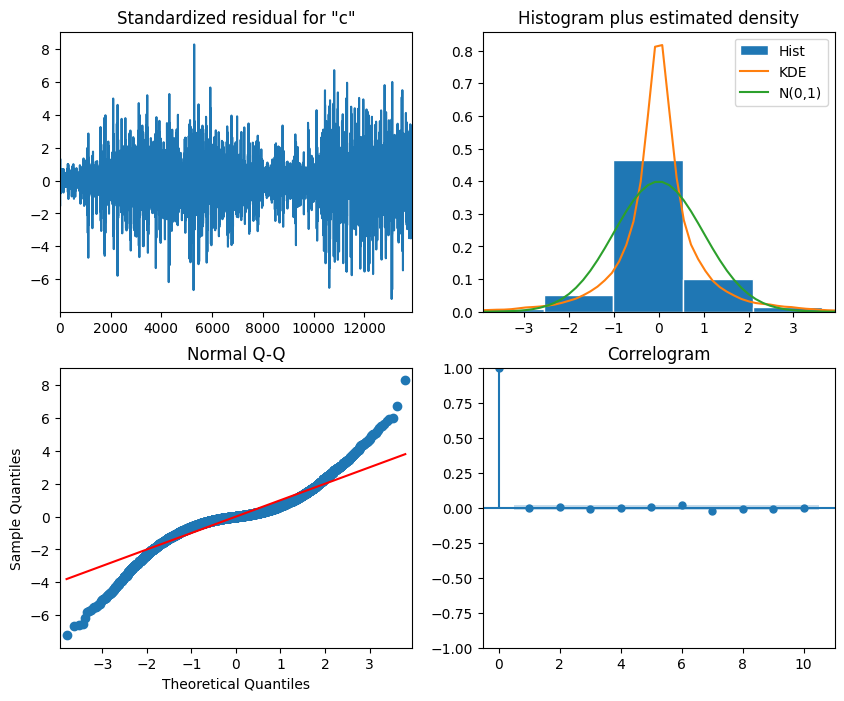

In [31]:
model = SARIMAX(y_casual_train_diff, order=(3,0,2),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));

### Log transformation to try to improve the residuals


In [35]:
y_casual_train_log = np.log1p(y_casual_train)
y_casual_train_log_diff = y_casual_train_log.diff(periods=24).dropna()

print(y_casual_train_log_diff)

24       0.223144
25      -1.504077
26      -1.098612
27      -0.287682
28       1.098612
           ...   
13898    0.382992
13899    0.405465
13900    0.439367
13901    0.492476
13902   -0.248697
Name: casual, Length: 13879, dtype: float64


In [38]:

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_casual_train_log_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_3128\1047722000.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\

,"(p,q)",AIC
0,"(3, 2)",29115.184718
1,"(3, 3)",29193.669686
2,"(2, 3)",29229.656796
3,"(3, 1)",29236.487364
4,"(1, 3)",29260.685317
5,"(2, 1)",29262.750730
6,"(1, 2)",29262.979537
7,"(1, 1)",29262.981350
8,"(2, 2)",29264.547936
9,"(3, 0)",29265.412416


c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\st

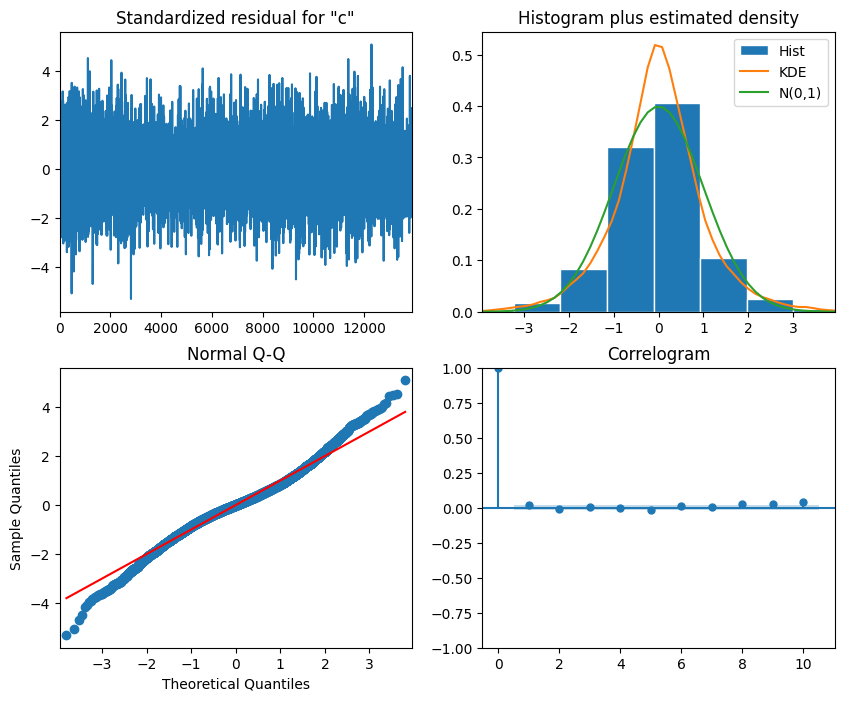

In [39]:
model = SARIMAX(y_casual_train_log_diff, order=(3,0,2),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));

With the log trasnformed target we achieve much better results

## Forecasting


In [45]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon
    end_idx = train_len

    if method == 'mean':
      pred_mean = []
      for i in range(train_len, total_len, window):
        mean = np.mean(df[:i].values)
        pred_mean.extend(mean for _ in range(window))
      return pred_mean

    elif method == 'last':
      pred_last_value = []
      for i in range(train_len, total_len, window):
        last_value = df[:i].iloc[-1]
        pred_last_value.extend(last_value for _ in range(window))
      return pred_last_value
    elif method == 'ARMA':
        pred_ARMA = []
        for i in range(train_len, total_len, window):
            train_slice = df[:i].reset_index(drop=True)  # ← Elimina el DatetimeIndex problemático
            model = SARIMAX(train_slice, order=(2, 0, 2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
        return pred_ARMA

In [46]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. PREPARACIÓN PREVIA (Asegurando que todo cuadra)
# ---------------------------------------------------------
# Creamos la serie completamente transformada que alimentará a la función
y_casual_log = np.log1p(y_casual)
y_casual_log_diff = y_casual_log.diff(periods=24).dropna()

# Ajustamos TRAIN_LEN: Como el .diff(24) borró las primeras 24 horas del dataset, 
# la longitud de tu Train ahora es 24 horas menor.
TRAIN_LEN = split_index - 24 
HORIZON = len(y_casual_test)
WINDOW = 2

# ---------------------------------------------------------
# 2. ENTRENAMIENTO Y PREDICCIÓN (Mundo Log-Diff)
# ---------------------------------------------------------
# Las predicciones que salen de aquí NO son bicis reales aún.
# Son "diferencias logarítmicas".
pred_mean_log_diff = rolling_forecast(y_casual_log_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_log_diff = rolling_forecast(y_casual_log_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_ARMA_log_diff = rolling_forecast(y_casual_log_diff, TRAIN_LEN, HORIZON, WINDOW, 'ARMA')

# ---------------------------------------------------------
# 3. REVERSIÓN Y CREACIÓN DEL DATAFRAME FINAL (Mundo Real)
# ---------------------------------------------------------
# Inicializamos el DataFrame final con los datos reales para comparar después
pred_df = pd.DataFrame(index=y_casual_test.index)
pred_df['Real_Bikes'] = y_casual_test.values

# PASO CLAVE: Rescatamos los valores de hace 24 horas... ¡Pero en formato LOGARITMO!
# Usamos .values para evitar problemas de índices desalineados al sumar.
past_log_values = y_casual_log.shift(24).loc[pred_df.index].values

# Revertimos MEAN
pred_mean_log = pred_mean_log_diff + past_log_values    # 1º Deshacer Diferencia
pred_df['pred_mean'] = np.expm1(pred_mean_log)          # 2º Deshacer Logaritmo

# Revertimos LAST VALUE
pred_last_log = pred_last_log_diff + past_log_values    # 1º Deshacer Diferencia
pred_df['pred_last_value'] = np.expm1(pred_last_log)    # 2º Deshacer Logaritmo

# Revertimos ARMA
pred_ARMA_log = pred_ARMA_log_diff + past_log_values    # 1º Deshacer Diferencia
pred_df['pred_ARMA'] = np.expm1(pred_ARMA_log)          # 2º Deshacer Logaritmo

# Comprobamos que ahora tenemos números normales (bicicletas)
print(pred_df.head())

       Real_Bikes  pred_mean  pred_last_value  pred_ARMA
13903          86  72.155135        55.926606  72.445181
13904          68  85.182761        66.064220  84.530372
13905          76  99.212159        79.232558  92.001800
13906         100  91.195186        72.813953  85.178052
13907         101  88.187715        96.706522  86.853853


### Measuring performance

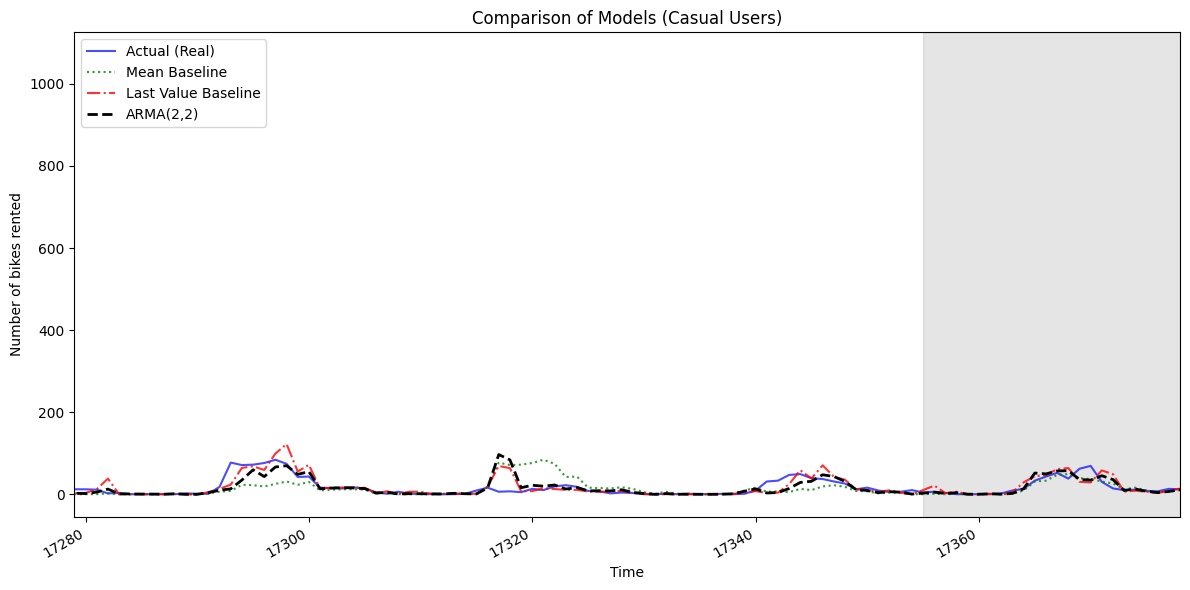

In [47]:
import matplotlib.pyplot as plt

# 1. Crear la figura
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Pintar la realidad (Test set)
ax.plot(pred_df['Real_Bikes'], 'b-', label='Actual (Real)', alpha=0.7)

# 3. Pintar las predicciones
ax.plot(pred_df['pred_mean'], 'g:', label='Mean Baseline', alpha=0.8)
ax.plot(pred_df['pred_last_value'], 'r-.', label='Last Value Baseline', alpha=0.8)
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(2,2)', linewidth=2)

# 4. Configuración de etiquetas y leyenda
ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Number of bikes rented')
ax.set_title('Comparison of Models (Casual Users)')

# 5. Sombreado y Zoom 
# Ajustamos el zoom a las últimas 100 horas para ver bien el detalle
last_idx = pred_df.index[-1]
start_zoom = pred_df.index[-100]

ax.set_xlim(start_zoom, last_idx)

# Sombreado de las últimas 24 horas (el horizonte final)
start_shade = pred_df.index[-24]
ax.axvspan(start_shade, last_idx, color='#808080', alpha=0.2, label='Forecast Horizon')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

--- Performance Report (MAPE) ---
                 Model      MAPE (%)
0        Mean Baseline  1.761197e+17
1  Last Value Baseline  6.438172e+16
2            ARMA(2,2)  6.189481e+16


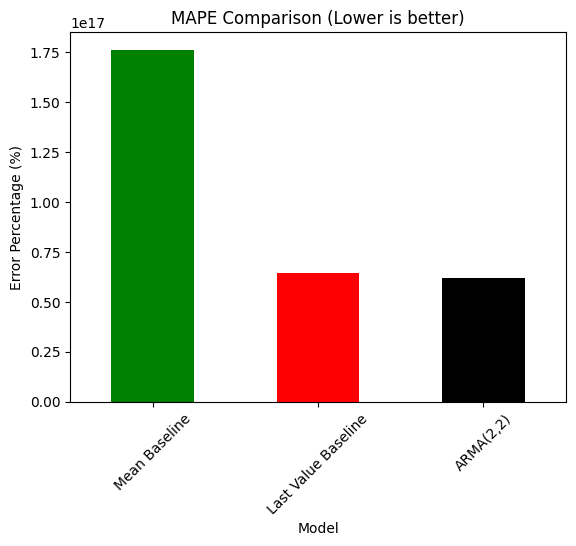

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculamos el MAPE para cada método
# Multiplicamos por 100 para tener el valor en porcentaje
mape_mean = mean_absolute_percentage_error(pred_df['Real_Bikes'], pred_df['pred_mean']) * 100
mape_last = mean_absolute_percentage_error(pred_df['Real_Bikes'], pred_df['pred_last_value']) * 100
mape_arma = mean_absolute_percentage_error(pred_df['Real_Bikes'], pred_df['pred_ARMA']) * 100

# Creamos una tabla comparativa para tu reporte
performance_report = pd.DataFrame({
    'Model': ['Mean Baseline', 'Last Value Baseline', 'ARMA(2,2)'],
    'MAPE (%)': [mape_mean, mape_last, mape_arma]
})

print("--- Performance Report (MAPE) ---")
print(performance_report)

# Visualización rápida del error
performance_report.plot(kind='bar', x='Model', y='MAPE (%)', color=['green', 'red', 'black'], legend=False)
plt.ylabel('Error Percentage (%)')
plt.title('MAPE Comparison (Lower is better)')
plt.xticks(rotation=45)
plt.show()

"""
--- Performance Report (MAPE) ---
                 Model      MAPE (%)
0        Mean Baseline  1.761197e+17
1  Last Value Baseline  6.438172e+16
2            ARMA(2,2)  6.189481e+16
"""


## Registered user

### AIC


In [ ]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
      try:
          model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
      except:
        continue
      aic = model.aic
      results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
    return result_df

In [ ]:
from itertools import product

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_registered_train_diff, order_list)
result_df

### Residual Analysis

In [ ]:
model = SARIMAX(y_registered_train_diff, order=(3,0,2),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));